In [11]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from scripts.utils import *
from scripts.plots import *
from scripts.pca import *
from scripts.lda import *
from scripts.classify_with_lda_pca import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
D,L,labels=init_dataset()
D,L,labels

(array([[ 1.85284048, -0.21530775,  0.04653456, ..., -0.06393955,
          1.06665359, -0.47186462],
        [-0.16436898,  1.63665974, -1.16487257, ..., -0.92205024,
          3.27717415, -0.37118987],
        [ 1.09839078, -0.61831145,  0.04392191, ...,  1.65445602,
         -0.53087884, -1.04041218],
        [-0.93073689,  0.99002204, -0.41369086, ..., -1.527528  ,
          1.42338924, -0.253746  ],
        [-1.0193342 ,  0.38670252, -1.08847926, ...,  1.87609599,
         -1.11381038, -0.02120134],
        [ 1.16696309,  1.15926273, -1.37988988, ...,  0.75929015,
         -0.15047129, -1.4376229 ]], shape=(6, 6000)),
 array([1., 0., 1., ..., 1., 0., 0.], shape=(6000,)),
 {1: 'True', 0: 'False'})

### First Principal Component

### 📘 Theory & Key Functions
**Theoretical Recall:** 
- **PCA (Principal Component Analysis)** is an *unsupervised* technique that projects data onto orthogonal directions that maximize the total variance, often used for dimensionality reduction/compression.
- **LDA (Linear Discriminant Analysis)** is a *supervised* technique that finds a linear subspace maximizing the Fisher ratio (between-class variance $S_B$ over within-class variance $S_W$), directly optimizing for class separability.

**Key Functions (from `pca.py` & `lda.py`):**
- `train_PCA(X, m)`: Computes the PCA projection matrix by extracting the top $m$ eigenvectors of the data covariance matrix.
- `train_LDA(X, L, m)`: Computes the LDA projection matrix by solving the generalized eigenvalue problem $S_B w = \lambda S_W w$.
- `apply_PCA()` / `apply_LDA()`: Project the original high-dimensional data onto the learned lower-dimensional subspaces.

### Principal Components 2-5 (Subsequent directions)

As we can see from the visualizations, PCA does not significantly help in this scenario since it is an unsupervised technique focused on maximizing variance rather than class separability.

Let's now move to LDA. See the implementation in [lda.py](../scripts/lda.py).

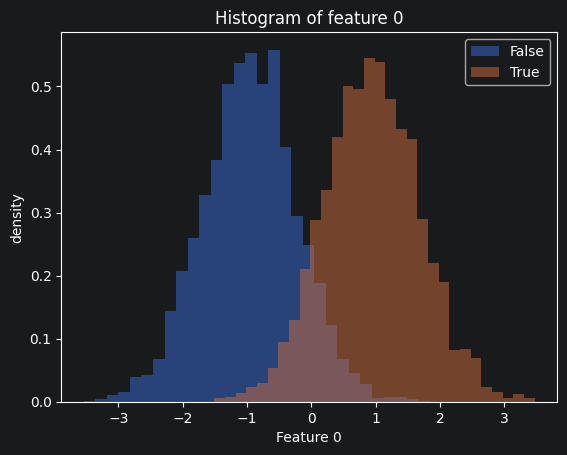

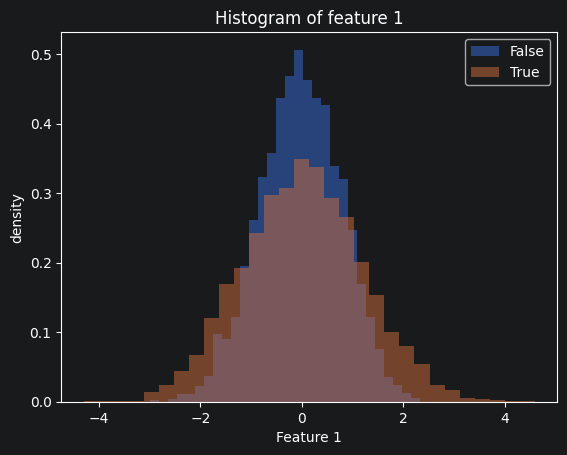

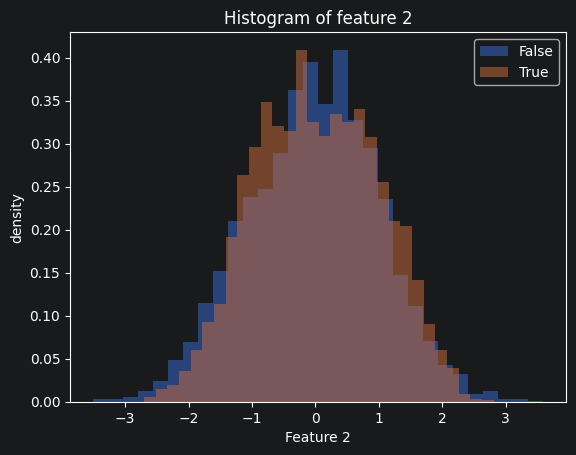

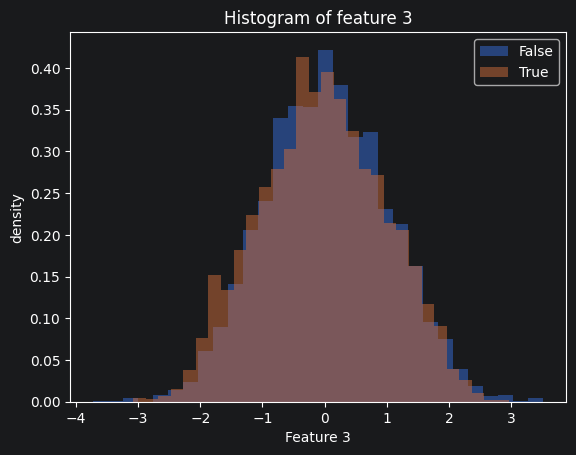

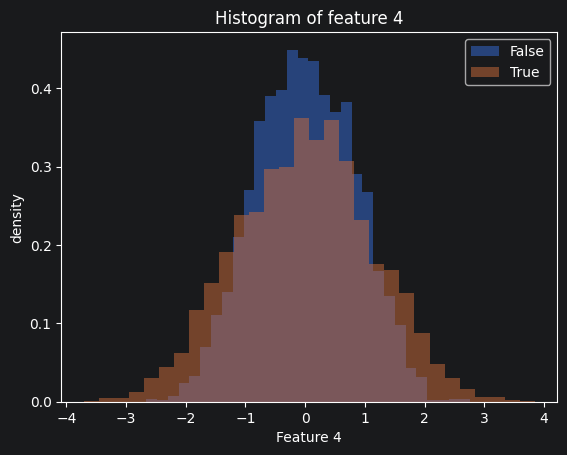

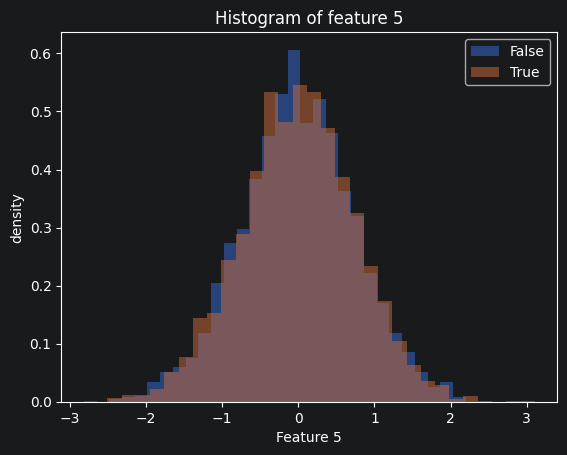

In [5]:
m=6
P,mu=train_PCA(D,m)
DP=apply_PCA(D,P,mu)
getHist(DP,L,labels)

In [106]:
# Salva gli istogrammi delle feature PCA
# def savePCAHist(D, L, m, classes):
#     C = getC(D)
#     _, U = np.linalg.eigh(C)
#     P = U[:, ::-1][:, 0:m]
#     DP = np.dot(P.T, D)
#     
#     for i in range(m):
#         plt.figure()
#         plt.ylabel("density")
#         plt.xlabel(f"Feature {i}")
#         for cnt in range(2):
#             mask = L == cnt
#             feature_data = DP[:, mask][i, :]
#             plt.hist(feature_data, bins=30, density=True, alpha=0.5, label=f"{classes[cnt]}")
#         
#         plt.legend()
#         plt.title(f"Histogram of feature {i}")
#         plt.tight_layout()
#         plt.savefig(f'../images/pca_histogram_feature_{i}.png', dpi=150, bbox_inches='tight')
#         plt.close()
#     print(f"Salvati {m} istogrammi PCA")

# savePCAHist(D, L, 6, labels)

Let's use the LDA threshold to classify the data. We will also apply PCA beforehand to see if we can improve the results.

In [6]:
Sb,Sw=compute_Sb_Sw(D,L)
print(f"La between class covariance matrix è {Sb} \n La within class covariance matrix è{Sw}")



La between class covariance matrix è [[ 1.36058485e-06  1.58737358e-05 -7.85114318e-04  7.78613509e-04
   4.06398379e-05 -1.73599814e-05]
 [ 1.58737358e-05  1.85196452e-04 -9.15980889e-03  9.08396495e-03
   4.74138784e-04 -2.02536252e-04]
 [-7.85114318e-04 -9.15980889e-03  4.53043771e-01 -4.49292533e-01
  -2.34508848e-02  1.00174347e-02]
 [ 7.78613509e-04  9.08396495e-03 -4.49292533e-01  4.45572355e-01
   2.32567096e-02 -9.93448957e-03]
 [ 4.06398379e-05  4.74138784e-04 -2.34508848e-02  2.32567096e-02
   1.21388712e-03 -5.18532032e-04]
 [-1.73599814e-05 -2.02536252e-04  1.00174347e-02 -9.93448957e-03
  -5.18532032e-04  2.21499565e-04]] 
 La within class covariance matrix è[[ 1.00134167e+00  5.15168444e-03  2.55257807e-03  1.37482622e-02
   9.96603919e-03 -1.29417640e-02]
 [ 5.15168444e-03  9.98167503e-01 -6.67560485e-03 -9.52461523e-03
  -4.48721195e-03 -6.15150847e-04]
 [ 2.55257807e-03 -6.67560485e-03  5.49438024e-01  1.22321515e-02
  -3.40917458e-03 -3.67354969e-03]
 [ 1.37482622e-0

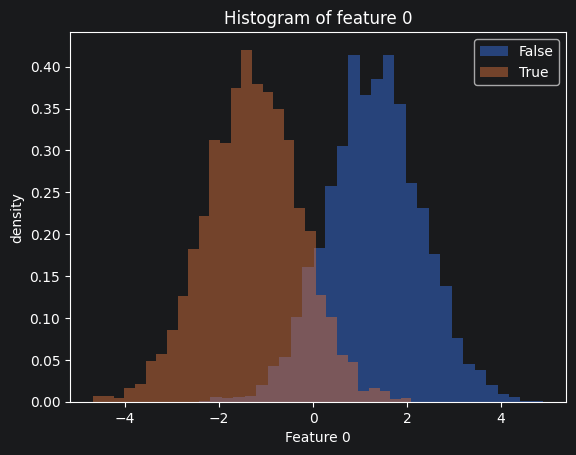

In [7]:

W=train_LDA(D,L,1)
DP=apply_LDA(D,W)
getHist(DP,L,labels)

Let's compare the results using PCA dimensions from 1 to 6.

In [109]:
# Salva istogramma LDA
# def saveLDAHist(D, L, m, classes):
#     Dlda = LDA(D, L, m)
#     plt.figure()
#     plt.ylabel("density")
#     plt.xlabel("LDA Direction")
#     for cnt in range(2):
#         mask = L == cnt
#         feature_data = Dlda[:, mask][0, :]
#         plt.hist(feature_data, bins=30, density=True, alpha=0.5, label=f"{classes[cnt]}")
#     
#     plt.legend()
#     plt.title("Histogram of LDA projection")
#     plt.tight_layout()
#     plt.savefig('../images/lda_histogram.png', dpi=150, bbox_inches='tight')
#     plt.close()
#     print("Salvato istogramma LDA")

# saveLDAHist(D, L, 1, labels)

In [8]:
(DTR, LTR), (DVAL, LVAL) = split_db_2to1(D, L)

### Conclusion on PCA+LDA

For the fingerprint spoofing detection dataset, the direct LDA approach on the 6 original features already provides excellent performance (90.7% accuracy). Using PCA with m=2-4 components offers a negligible improvement (0.1%), which does not justify the added complexity of the pipeline. In real-world application scenarios, the simplicity and interpretability of pure LDA would be preferable, unless specific computational constraints or noise reduction needs arise.

In [10]:
classify_with_LDA(DTR,LTR,DVAL,LVAL)


Threshold: -0.018534376786207174
Mean False: -1.2975902799385062 Mean True: 1.2605215263660918
Labels:      [0. 0. 1. ... 0. 0. 0.]
Predictions: [0 0 1 ... 0 0 0]
Number of errors: 186 (out of 2000 samples)
Error rate: 9.3%


### LDA with different training data size

Let's try to train LDA with a reduced dataset (1/50 of the training set).

Performance degrades significantly.

In [12]:
# Analizza le prestazioni in funzione di m
print("Analisi PCA + LDA: Error rate vs numero di dimensioni PCA\n")
for m in range(1, 7):
    error_rate = classify_with_PCA_and_LDA(D, L, m)
    print(f"m = {m}: Error rate = {error_rate:.1f}%")

Analisi PCA + LDA: Error rate vs numero di dimensioni PCA

m = 1: Error rate = 9.3%
m = 2: Error rate = 9.2%
m = 3: Error rate = 9.2%
m = 4: Error rate = 9.2%
m = 5: Error rate = 9.3%
m = 6: Error rate = 9.3%


### PCA with different training data size

Let's try to apply PCA on the reduced dataset (1/50 of the training set) and then classify with LDA.